## Coding Exercise #0304

### 1. Quantile:

In [30]:
import scipy.stats as st
import numpy as np

#### 1.1. Standard Normal:

In [31]:
# Standard Normal corresponds to mu = 0 and sigma = 1.
mu = 0
sigma = 1

In [32]:
# Quantile at alpha = 0.95
# This is useful when calculating 90% confidence interval.
alpha = 0.95
st.norm.ppf(alpha, loc = mu , scale = sigma)

np.float64(1.6448536269514722)

In [33]:
# Quantile at alpha = 0.975
# This is useful when calculating 95% confidence interval.
alpha = 0.975
st.norm.ppf(alpha, loc = mu , scale = sigma)

np.float64(1.959963984540054)

#### 1.2. Student-t:

In [34]:
# Quantiles at alpha = 0.95 with changing degree of freedom.
alpha=0.95
for df in [10,50,100,2000,100000]:
    val = st.t.ppf(alpha,df)
    print( 'Degree of Freedom = %7d,  Quantile = %10f' %(df,val))

Degree of Freedom =      10,  Quantile =   1.812461
Degree of Freedom =      50,  Quantile =   1.675905
Degree of Freedom =     100,  Quantile =   1.660234
Degree of Freedom =    2000,  Quantile =   1.645616
Degree of Freedom =  100000,  Quantile =   1.644869


In [35]:
# Quantiles at alpha = 0.975 with changing degree of freedom.
alpha=0.95
alpha=0.975
for df in [10,50,100,2000,100000]:
    val = st.t.ppf(alpha,df)
    print( 'Degree of Freedom = %7d,  Quantile = %10f' %(df,val))

Degree of Freedom =      10,  Quantile =   2.228139
Degree of Freedom =      50,  Quantile =   2.008559
Degree of Freedom =     100,  Quantile =   1.983972
Degree of Freedom =    2000,  Quantile =   1.961151
Degree of Freedom =  100000,  Quantile =   1.959988


#### 1.3. Chi-square:

In [36]:
# P(X <= 8) with degree of freedom = 5.
df = 5
st.chi2.cdf(8, df)

np.float64(0.8437643724222779)

In [37]:
# Quantile at alpha = 0.843764373 with degree of freedom = 5
df = 5
alpha = 0.843764373
st.chi2.ppf(alpha, df)

np.float64(8.000000010482703)

*So, have verified that the Quantile is indeed an inverse function of the CDF.*

In [38]:
data = [12, 15, 18, 21, 24, 27, 30, 33, 36, 39]
# Calculate quantiles
q1 = np.quantile(data, 0.25) # 25th percentile
q2 = np.quantile(data, 0.50) # 50th percentile (median)
q3 = np.quantile(data, 0.75) # 75th percentile
q90 = np.quantile(data, 0.90) # 90th percentile
print("Q1 (25%):", q1)
print("Q2 (Median):", q2)
print("Q3 (75%):", q3)
print("90th Percentile:", q90)

Q1 (25%): 18.75
Q2 (Median): 25.5
Q3 (75%): 32.25
90th Percentile: 36.3


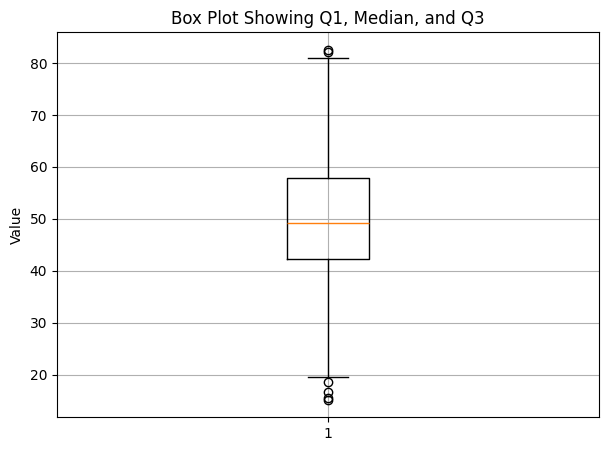

In [39]:
import matplotlib.pyplot as plt
# Generate random data
data = np.random.normal(loc=50, scale=12, size=500)
plt.figure(figsize=(7, 5))
plt.boxplot(data, vert=True)
plt.title("Box Plot Showing Q1, Median, and Q3")
plt.ylabel("Value")
plt.grid(True)
plt.show()

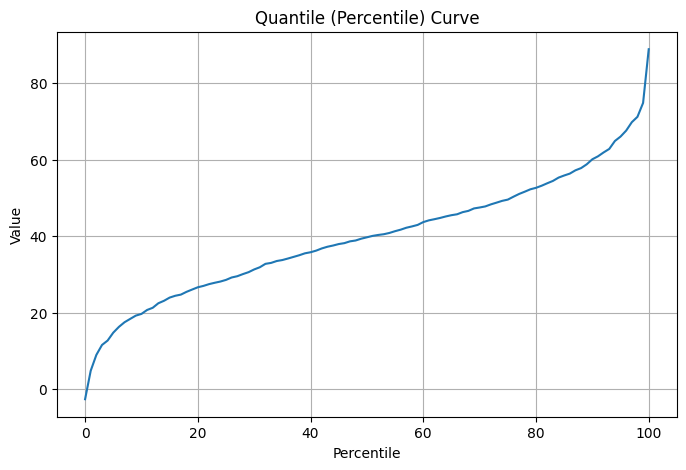

In [40]:
# Generate random data
data = np.random.normal(loc=40, scale=15, size=1000)
# Calculate percentiles for every 1%
percentiles = np.arange(0, 101, 1)
values = np.percentile(data, percentiles)
plt.figure(figsize=(8, 5))
plt.plot(percentiles, values)
plt.title("Quantile (Percentile) Curve")
plt.xlabel("Percentile")
plt.ylabel("Value")
plt.grid(True)
plt.show()

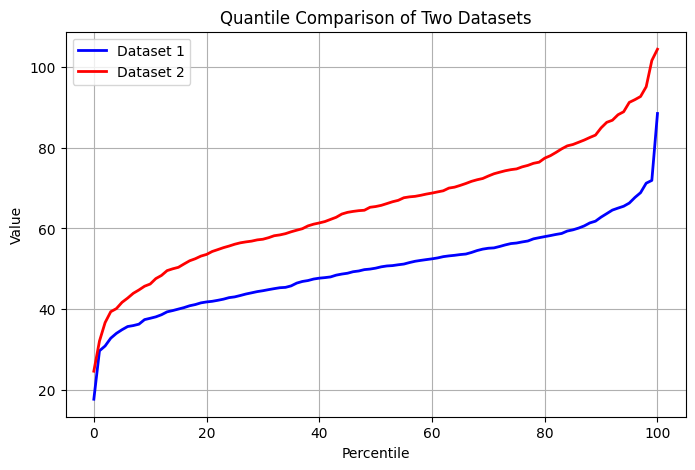

In [50]:
## Compare quantiles of two datasets
# Generate two random datasets
np.random.seed(42)
data1 = np.random.normal(loc=50, scale=10, size=500)
data2 = np.random.normal(loc=55, scale=15, size=500) + 10
# Calculate percentiles for 0 to 100%
percentiles = np.arange(0, 101, 1)
values1 = np.percentile(data1, percentiles)
values2 = np.percentile(data2, percentiles)
plt.figure(figsize=(8, 5))
plt.plot(percentiles, values1, label='Dataset 1', color='blue', linewidth=2)
plt.plot(percentiles, values2, label='Dataset 2', color='red', linewidth=2)
plt.title("Quantile Comparison of Two Datasets")
plt.xlabel("Percentile")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

### Central Limit theorem

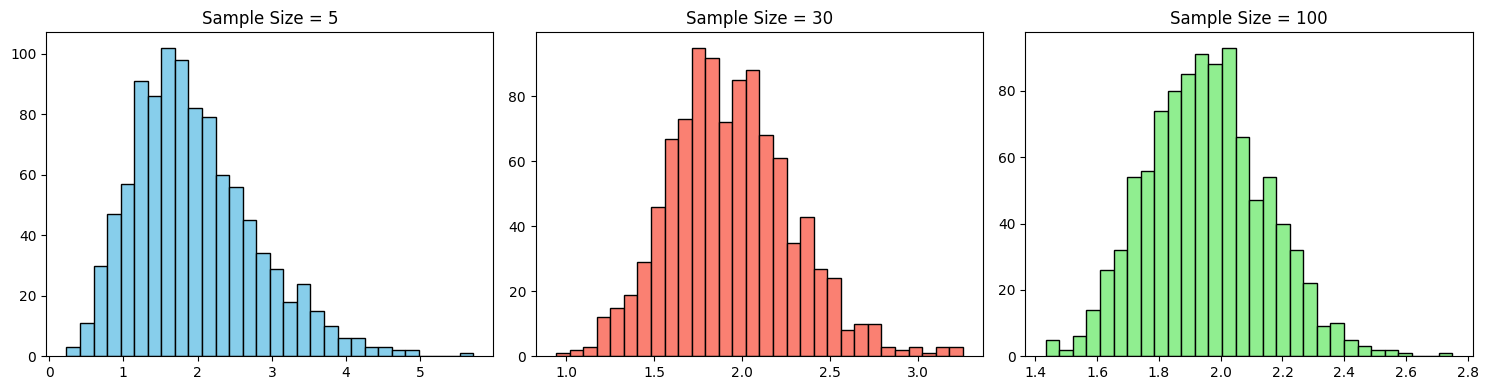

In [51]:
##Step 1: Generate a non-normal dataset(right skewed)
population = np.random.exponential(scale=2.0, size=10000)
# Step 2: Draw random samples and compute their means
def sample_means(sample_size, num_samples):
    means = []
    for _ in range(num_samples):
        sample = np.random.choice(population, size=sample_size, replace=True)
        means.append(np.mean(sample))
    return means

#Step 3: Generate sample means for different sample sizes
means_5 = sample_means(sample_size=5, num_samples=1000)
means_30 = sample_means(sample_size=30, num_samples=1000)
means_100 = sample_means(sample_size=100, num_samples=1000)

#Step 4: Plot histograms of sample means
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.hist(means_5, bins=30, color='skyblue', edgecolor='black')
plt.title('Sample Size = 5')
plt.subplot(1, 3, 2)
plt.hist(means_30, bins=30, color='salmon', edgecolor='black')
plt.title('Sample Size = 30')
plt.subplot(1, 3, 3)
plt.hist(means_100, bins=30, color='lightgreen', edgecolor='black')
plt.title('Sample Size = 100')
plt.tight_layout()
plt.show()

### Standard Error

In [55]:
sample = [12,15,18,21,24,27,30,33,36,39]
sample_std = np.std(sample, ddof=1)
n = len(sample)
standard_error = sample_std / np.sqrt(n)
print("Sample Standard Deviation:", round(sample_std, 3))
print("Standard Error:", round(standard_error, 3))

Sample Standard Deviation: 9.083
Standard Error: 2.872


### Standard Error for randomely generated sample

In [62]:
sample = np.random.normal(loc=50, scale=12, size=30)
n = len(sample)
sample_std = np.std(sample, ddof=1)
standard_error = sample_std / np.sqrt(n)
print("Sample Standard Deviation:", round(sample_std, 3))
print("Standard Error:", round(standard_error, 3))

Sample Standard Deviation: 10.426
Standard Error: 1.903
